# Analisis Regresi dengan Scikit-learn

## 1. Persiapan Data

In [ ]:
import pandas as pd

# Memuat dataset
df = pd.read_csv('/content/diabetes[1].csv')

# Menampilkan 5 baris pertama dataset
print("5 Baris Pertama Dataset:")
display(df.head())

5 Baris Pertama Dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Menampilkan informasi umum tentang dataset
print("\nInformasi Dataset:")
df.info()

# Menampilkan statistik deskriptif dataset
print("\nStatistik Deskriptif Dataset:")
display(df.describe())


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Statistik Deskriptif Dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Deskripsi Dataset
Dataset yang digunakan adalah `diabetes[1].csv`. Dataset ini tampaknya berisi informasi kesehatan pasien yang terkait dengan diabetes. Berikut adalah fitur-fitur yang ada dalam dataset:

*   **Pregnancies**: Jumlah kehamilan.
*   **Glucose**: Konsentrasi glukosa plasma 2 jam dalam tes toleransi glukosa oral.
*   **BloodPressure**: Tekanan darah diastolik (mm Hg).
*   **SkinThickness**: Ketebalan lipatan kulit trisep (mm).
*   **Insulin**: Insulin serum 2 jam (mu U/ml).
*   **BMI**: Indeks Massa Tubuh (berat dalam kg/(tinggi dalam m)^2).
*   **DiabetesPedigreeFunction**: Fungsi silsilah diabetes.
*   **Age**: Usia (tahun).
*   **Outcome**: Variabel kelas (0 atau 1), di mana 1 berarti diabetes dan 0 berarti tidak diabetes. Ini adalah variabel target kita.

Dataset ini memiliki **`8 fitur independen`** dan **`1 fitur dependen (Outcome)`**. Jumlah data adalah **`768`** baris.

## 2. Eksplorasi Data (EDA)

Pada bagian ini, kita akan melakukan eksplorasi data untuk memahami karakteristik dataset lebih lanjut, terutama hubungan antara variabel independen dan variabel dependen (`Outcome`).

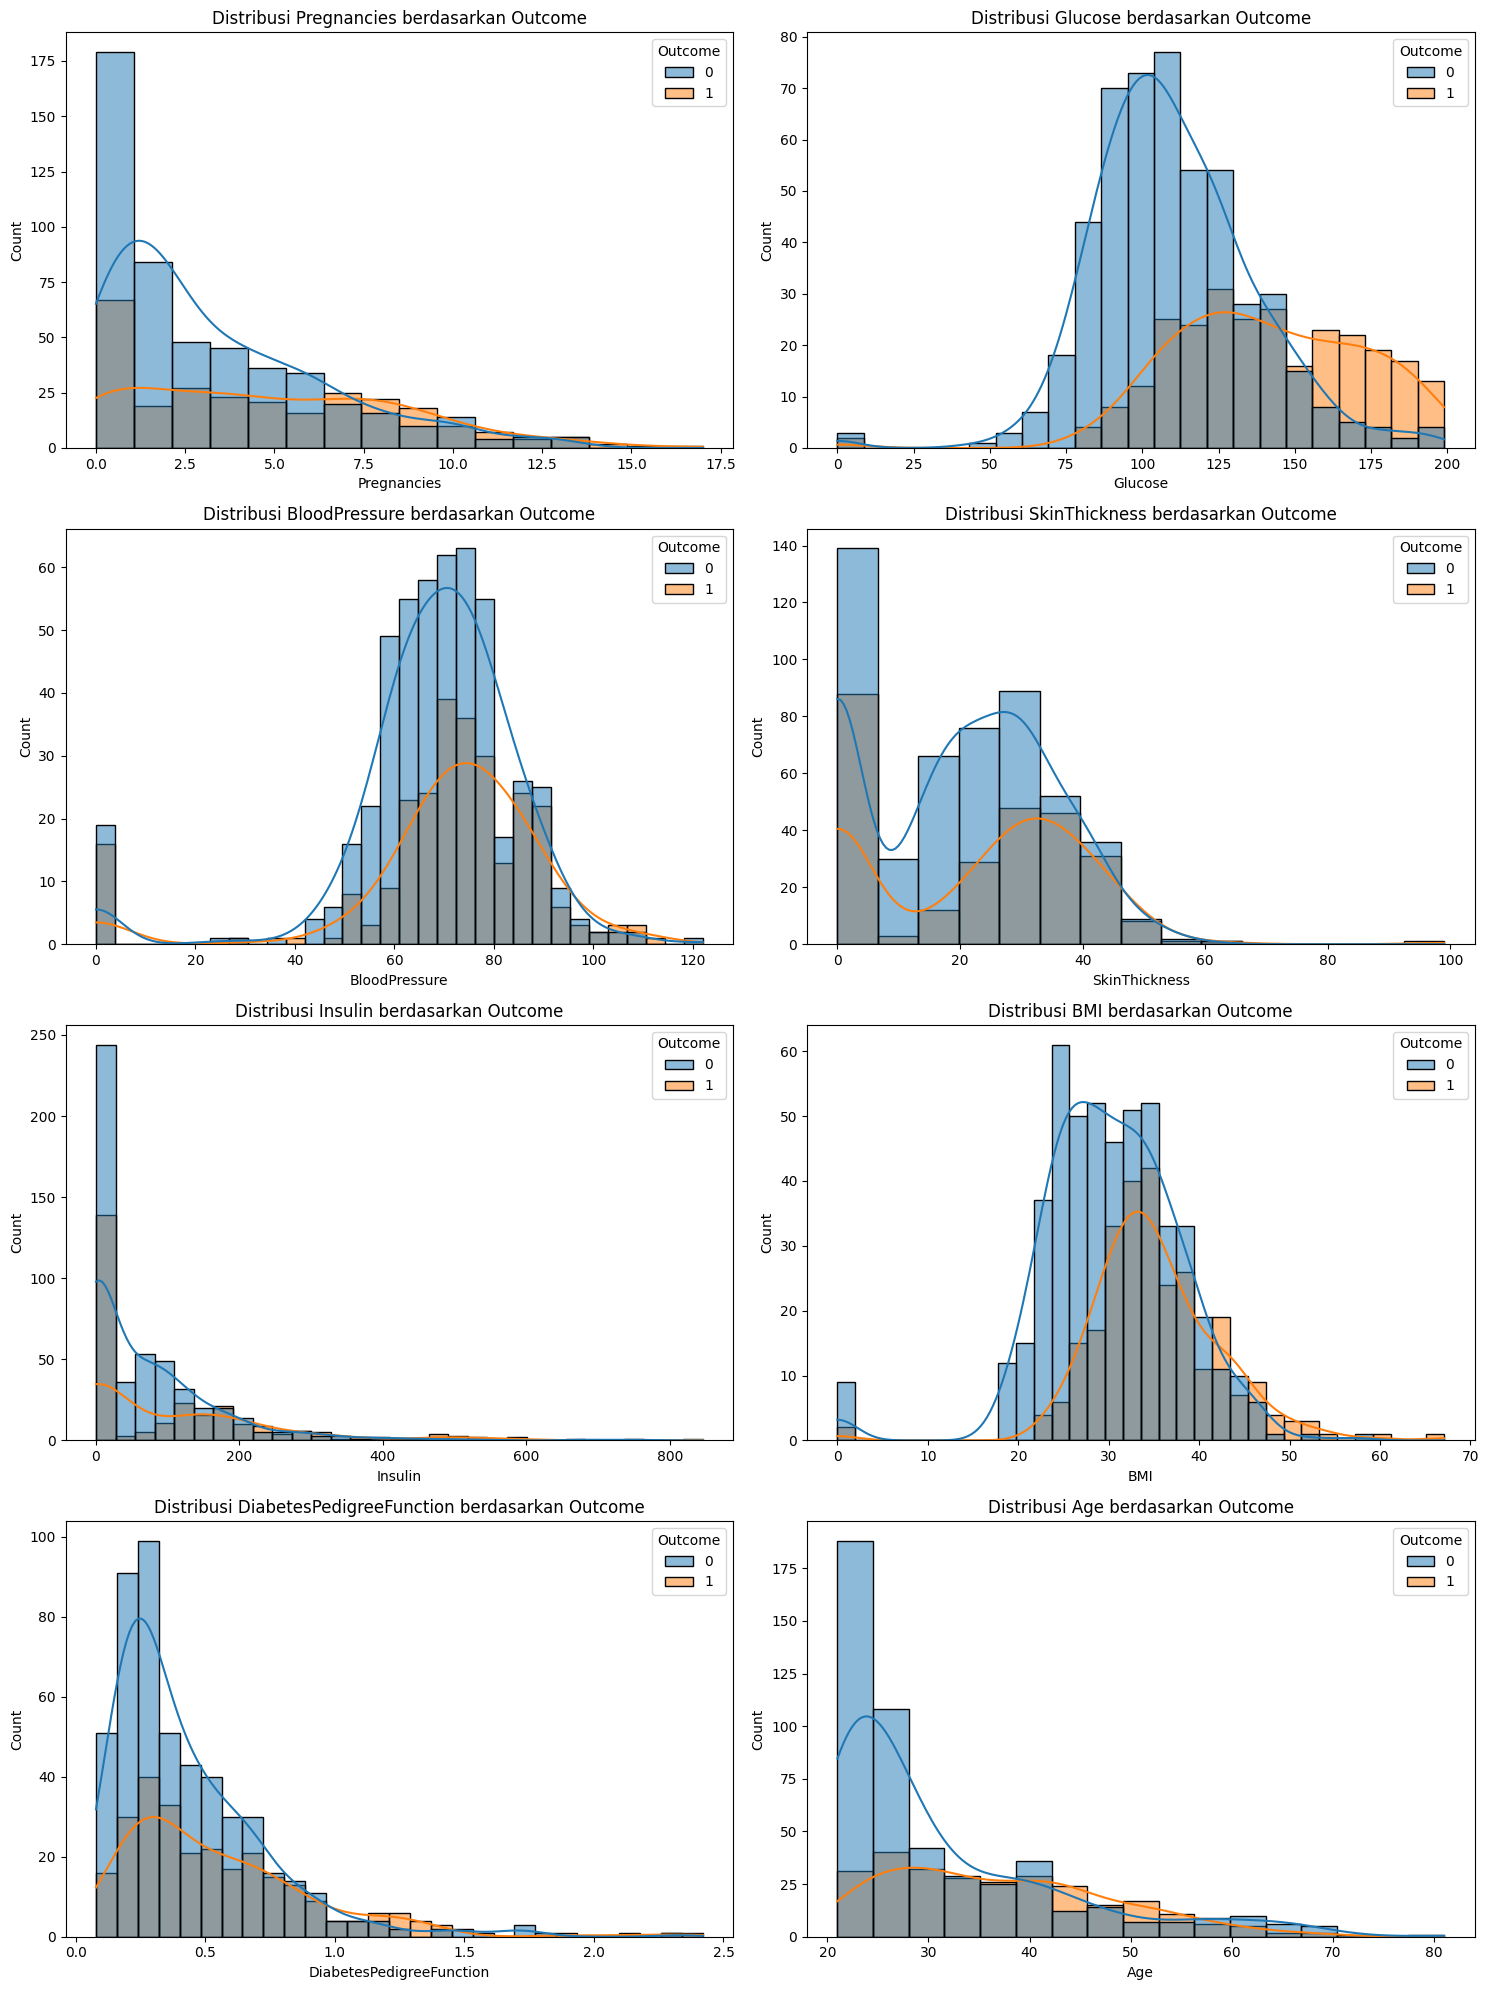

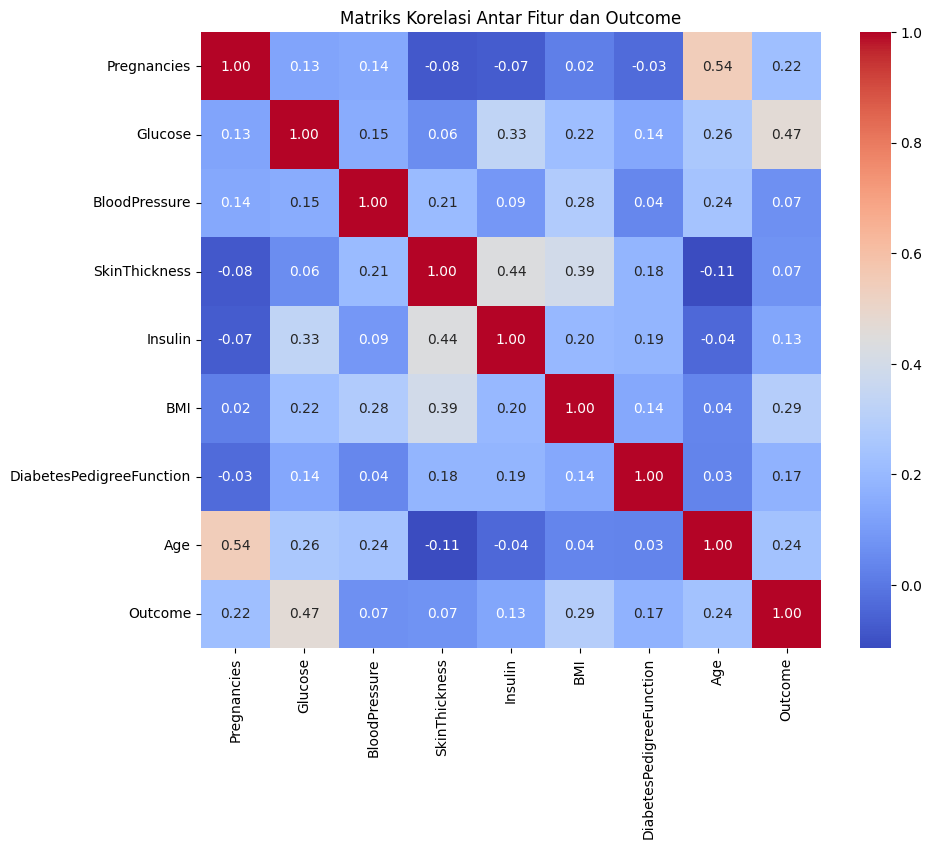

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memisahkan fitur (X) dan target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Membuat visualisasi distribusi fitur untuk kedua kelas Outcome
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, column in enumerate(X.columns):
    sns.histplot(data=df, x=column, hue='Outcome', kde=True, ax=axes[i])
    axes[i].set_title(f'Distribusi {column} berdasarkan Outcome')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Menampilkan korelasi antara fitur dan target
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Antar Fitur dan Outcome')
plt.show()

### Analisis Visualisasi EDA

Dari visualisasi distribusi di atas, kita dapat mengamati beberapa hal:

*   **Glucose**: Individu dengan glukosa yang lebih tinggi cenderung memiliki `Outcome` 1 (diabetes).
*   **BMI**: Sama seperti glukosa, individu dengan BMI yang lebih tinggi juga menunjukkan kecenderungan yang lebih besar untuk memiliki `Outcome` 1.
*   **Age**: Kelompok usia yang lebih tua memiliki proporsi `Outcome` 1 yang lebih tinggi.
*   **Insulin, Pregnancies, BloodPressure, SkinThickness, DiabetesPedigreeFunction**: Hubungannya dengan `Outcome` tidak sejelas Glukosa, BMI, atau Usia, namun masih terlihat beberapa pola.

Matriks korelasi juga memberikan informasi kuantitatif mengenai hubungan antar variabel. Korelasi positif yang kuat antara fitur-fitur seperti `Glucose`, `BMI`, dan `Age` dengan `Outcome` mengindikasikan bahwa fitur-fitur ini adalah prediktor yang baik untuk diabetes.

## 3. Pembangunan Model

Pada bagian ini, kita akan mempersiapkan data untuk pembangunan model dengan memisahkan fitur dan variabel target, kemudian membagi data menjadi set pelatihan (training set) dan set pengujian (testing set). Setelah itu, kita akan melatih model regresi linear menggunakan `LinearRegression` dari `sklearn.linear_model`.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Memisahkan fitur (X) dan variabel target (y)
X = df.drop('Outcome', axis=1) # Fitur adalah semua kolom kecuali 'Outcome'
y = df['Outcome']              # Variabel target adalah 'Outcome'

# Membagi data menjadi training set dan testing set
# Ukuran testing set adalah 20% dari total data, dan random_state digunakan untuk reproduktibilitas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ukuran Training Set: {X_train.shape[0]} baris")
print(f"Ukuran Testing Set: {X_test.shape[0]} baris")

# Inisialisasi model Linear Regression
model = LinearRegression()

# Melatih model dengan data training
model.fit(X_train, y_train)

print("\nModel Linear Regression berhasil dilatih.")

Ukuran Training Set: 614 baris
Ukuran Testing Set: 154 baris

Model Linear Regression berhasil dilatih.


## 4. Evaluasi Model

Pada bagian ini, kita akan mengevaluasi performa model regresi linear yang telah dilatih menggunakan data pengujian. Evaluasi akan mencakup pembuatan prediksi, analisis koefisien model (slope dan intercept), serta penghitungan metrik performa seperti R2 Score atau Mean Squared Error (MSE).

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Melakukan prediksi pada data testing
y_pred = model.predict(X_test)

print("Prediksi berhasil dilakukan pada data testing.")

# Menampilkan koefisien regresi (slope) untuk setiap fitur
print("\nKoefisien Regresi (Slope) untuk setiap fitur:")
for i, col in enumerate(X.columns):
    print(f"  {col}: {model.coef_[i]:.4f}")

# Menampilkan nilai intercept
print(f"\nNilai Intercept: {model.intercept_:.4f}")

# Menghitung Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"\nMean Squared Error (MSE): {mse:.4f}")

# Menghitung R2 Score
r2 = r2_score(y_test, y_pred)
print(f"R2 Score: {r2:.4f}")

Prediksi berhasil dilakukan pada data testing.

Koefisien Regresi (Slope) untuk setiap fitur:
  Pregnancies: 0.0105
  Glucose: 0.0056
  BloodPressure: -0.0023
  SkinThickness: 0.0005
  Insulin: -0.0003
  BMI: 0.0150
  DiabetesPedigreeFunction: 0.1113
  Age: 0.0065

Nilai Intercept: -0.9488

Mean Squared Error (MSE): 0.1710
R2 Score: 0.2550


## 5. Visualisasi Hasil

Pada bagian ini, kita akan membuat visualisasi untuk membandingkan nilai prediksi model dengan nilai aktual pada data testing. Karena `Outcome` adalah variabel biner (0 atau 1) dan kita menggunakan `LinearRegression` yang menghasilkan nilai kontinu, kita akan memplot prediksi tersebut dan melihat bagaimana distribusinya dibandingkan dengan label aktual.

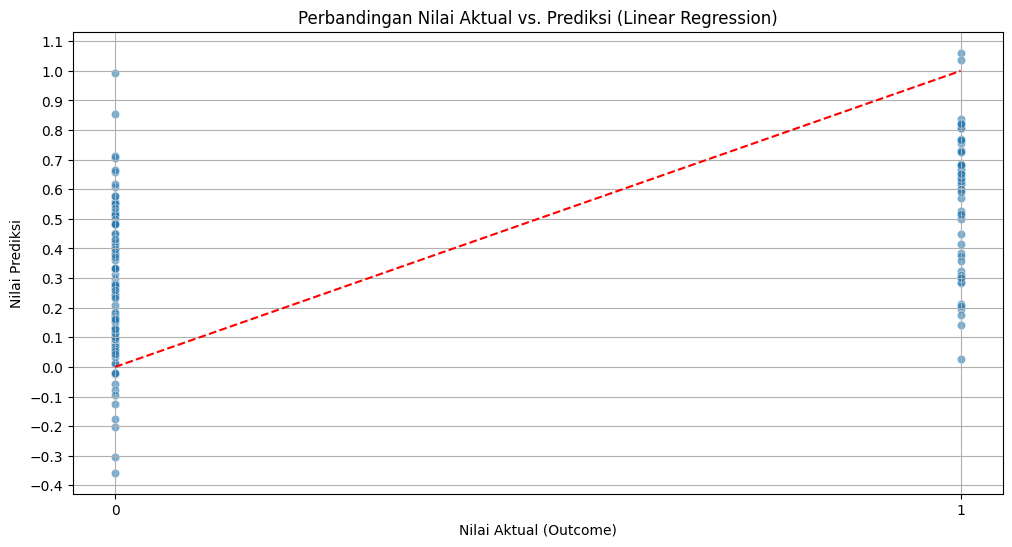

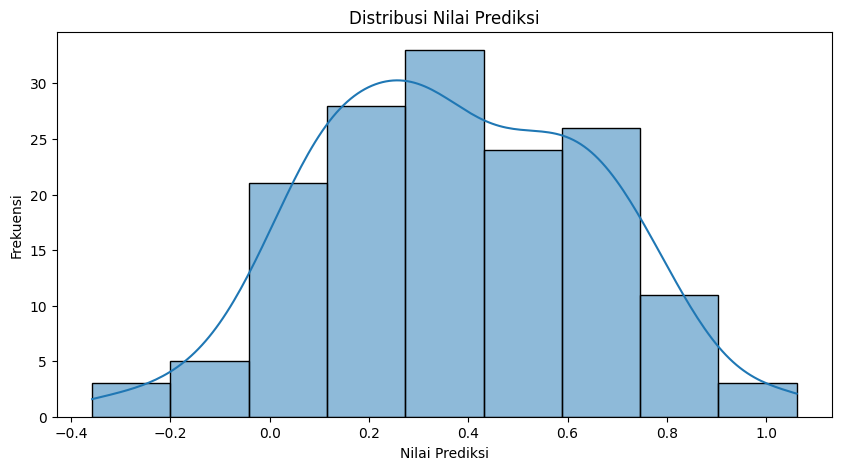

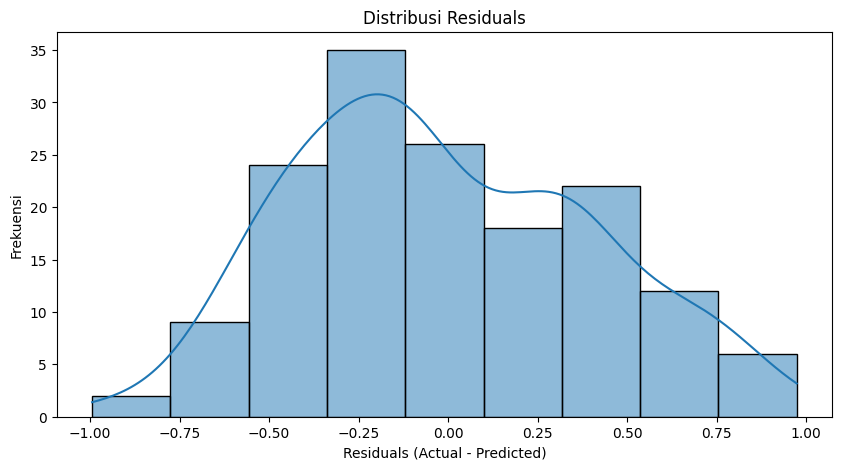

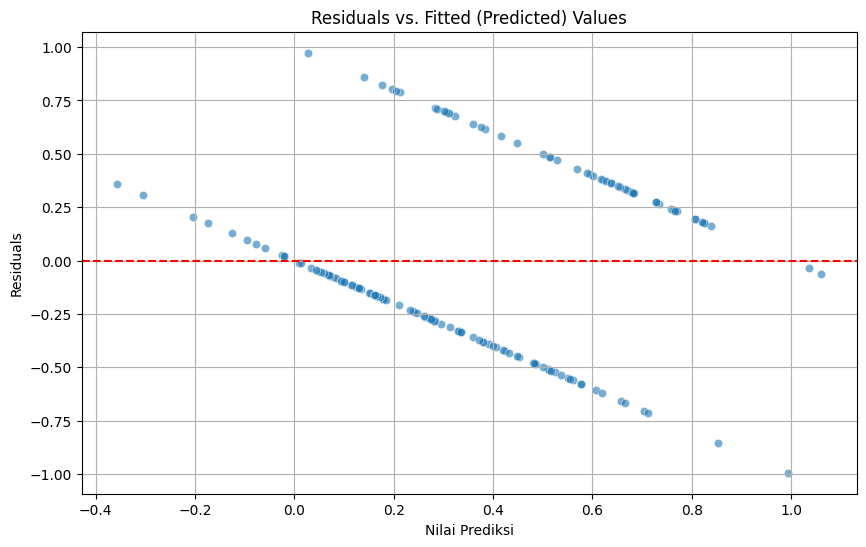

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Gabungkan nilai aktual dan prediksi ke dalam DataFrame untuk kemudahan visualisasi
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# Visualisasi perbandingan nilai aktual vs prediksi
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Actual', y='Predicted', data=results_df, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--') # Garis y=x
plt.title('Perbandingan Nilai Aktual vs. Prediksi (Linear Regression)')
plt.xlabel('Nilai Aktual (Outcome)')
plt.ylabel('Nilai Prediksi')
plt.xticks([0, 1]) # Karena Outcome hanya 0 atau 1
plt.yticks(np.arange(np.floor(y_pred.min() * 10) / 10, np.ceil(y_pred.max() * 10) / 10 + 0.1, 0.1))
plt.grid(True)
plt.show()

# Visualisasi distribusi nilai prediksi
plt.figure(figsize=(10, 5))
sns.histplot(results_df['Predicted'], kde=True)
plt.title('Distribusi Nilai Prediksi')
plt.xlabel('Nilai Prediksi')
plt.ylabel('Frekuensi')
plt.show()

# Visualisasi Residuals (selisih antara aktual dan prediksi)
residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True)
plt.title('Distribusi Residuals')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frekuensi')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs. Fitted (Predicted) Values')
plt.xlabel('Nilai Prediksi')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

## 6. Analisis dan Kesimpulan

### Interpretasi Hasil Model:
*   **Koefisien (Slope)**: Koefisien menunjukkan seberapa besar perubahan variabel target (`Outcome`) yang diprediksi untuk setiap peningkatan satu unit pada fitur independen, dengan asumsi fitur lainnya konstan. Koefisien positif (misalnya `Glucose`, `BMI`, `Age`, `Pregnancies`, `DiabetesPedigreeFunction`) menunjukkan hubungan positif dengan `Outcome`, artinya semakin tinggi nilai fitur tersebut, semakin tinggi kemungkinan `Outcome` menjadi 1 (diabetes). Sebaliknya, koefisien negatif (misalnya `BloodPressure`, `Insulin`, `SkinThickness`) menunjukkan hubungan negatif.
*   **Intercept**: Intercept (-0.9488) adalah nilai `Outcome` yang diprediksi ketika semua fitur independen bernilai nol. Dalam konteks medis, banyak fitur yang bernilai nol mungkin tidak realistis (misalnya Glukosa nol), sehingga interpretasi langsung dari intercept ini harus dilakukan dengan hati-hati dan lebih dilihat sebagai penyesuaian dasar model.

### Seberapa Baik Model Memprediksi Data?
*   **R2 Score (0.2550)**: R2 Score yang relatif rendah menunjukkan bahwa model regresi linear ini hanya mampu menjelaskan sekitar 25.5% variabilitas dalam data `Outcome`. Ini mengindikasikan bahwa sebagian besar variasi `Outcome` tidak dapat dijelaskan oleh fitur-fitur yang digunakan dalam model ini. Model tidak memiliki daya prediksi yang kuat.
*   **Mean Squared Error (MSE) (0.1710)**: MSE menunjukkan rata-rata kuadrat kesalahan prediksi. Nilai ini memberikan gambaran tentang seberapa jauh rata-rata prediksi model dari nilai aktual. Walaupun tidak ada ambang batas "baik" yang universal, nilai ini harus dipertimbangkan dalam konteks skala variabel target. Untuk target biner 0 atau 1, MSE 0.1710 menunjukkan kesalahan yang cukup signifikan.
*   **Visualisasi Aktual vs Prediksi**: Dari plot, terlihat bahwa prediksi model cenderung mengelompok di antara 0 dan 1, namun tidak ada garis regresi yang jelas yang memisahkan kedua kelas. Banyak prediksi berada di antara 0 dan 1 yang seharusnya mengindikasikan 'tidak diabetes' atau 'diabetes'. Idealnya, untuk masalah klasifikasi, kita ingin prediksi mendekati 0 untuk kelas 0 dan mendekati 1 untuk kelas 1.

### Apakah Ada Indikasi Overfitting atau Underfitting?
*   **Underfitting**: R2 Score yang rendah (0.2550) dan nilai MSE yang relatif tinggi sangat mengindikasikan **underfitting**. Ini berarti model terlalu sederhana untuk menangkap pola yang mendasari dalam data. Model tidak mampu mempelajari hubungan yang kompleks antara fitur dan target, sehingga performanya buruk pada data pelatihan maupun data pengujian.
*   **Penyebab Underfitting**: Penyebab utama underfitting di sini adalah penggunaan `LinearRegression` untuk masalah klasifikasi biner. Regresi linear mengasumsikan hubungan linier antara fitur dan target, serta target yang kontinu. Karena `Outcome` hanya bisa 0 atau 1, model regresi linear tidak cocok dan secara inheren akan kesulitan dalam membuat prediksi yang akurat.

### Kesimpulan:
Model `LinearRegression` yang diterapkan pada dataset diabetes ini menunjukkan performa yang kurang baik dalam memprediksi `Outcome` (diabetes) karena rendahnya R2 Score dan distribusi prediksi yang tidak ideal. Ini sebagian besar disebabkan oleh ketidaksesuaian model regresi linear dengan jenis variabel target biner. Untuk masalah klasifikasi seperti ini, **Regresi Logistik (`LogisticRegression`)** atau algoritma klasifikasi lainnya (misalnya Support Vector Machine, Decision Tree, Random Forest) akan menjadi pilihan yang jauh lebih tepat dan kemungkinan besar akan menghasilkan performa model yang lebih baik.